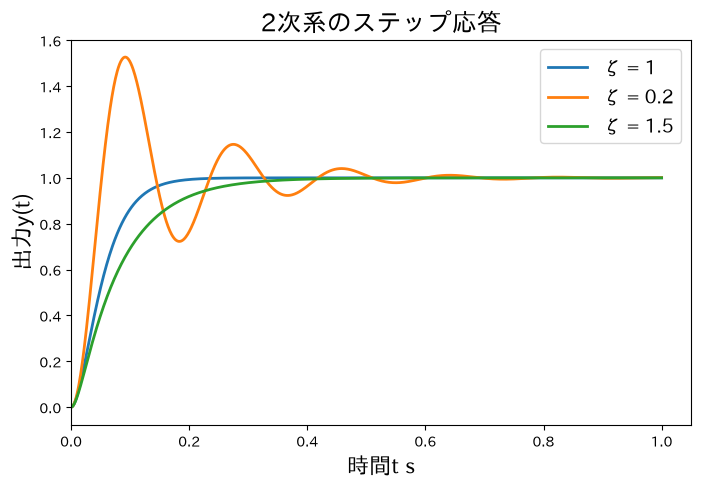

In [1]:
from control.matlab import *
import matplotlib.pyplot as plt
import japanize_matplotlib 
import numpy as np

# パラメータの設定
omega_n = 35 # 固有角周波数
zetas = [1, 0.2, 1.5] # 重ね書きしたい減衰比のリスト

# 共通の時間軸を定義（0秒から1.0秒まで、1000分割）
T_sim = np.linspace(0, 1.0, 1000)

# グラフの準備
plt.figure(figsize=(8, 5))

# それぞれのζについて計算とプロットを繰り返す
for zeta in zetas:
    # 伝達関数を定義
    den = [1, 2*zeta*omega_n, omega_n**2]
    num = [omega_n**2]
    system = tf(num, den)

    # ステップ応答を計算（定義した時間軸 T_sim を指定する）
    (yout, T) = step(system, T=T_sim)

    # プロット（labelを指定して凡例用のお名前をつける）
    plt.plot(T, yout, linewidth=2, label=f'ζ = {zeta}')

# グラフの装飾
plt.title('2次系のステップ応答', fontsize=18)
plt.xlabel('時間t s', fontsize=16)
plt.ylabel('出力y(t)', fontsize=16)
plt.legend(fontsize=14) # 凡例を表示
plt.xlim(xmin=0) # 横軸を0からスタートさせる

plt.savefig('./images/step_response_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

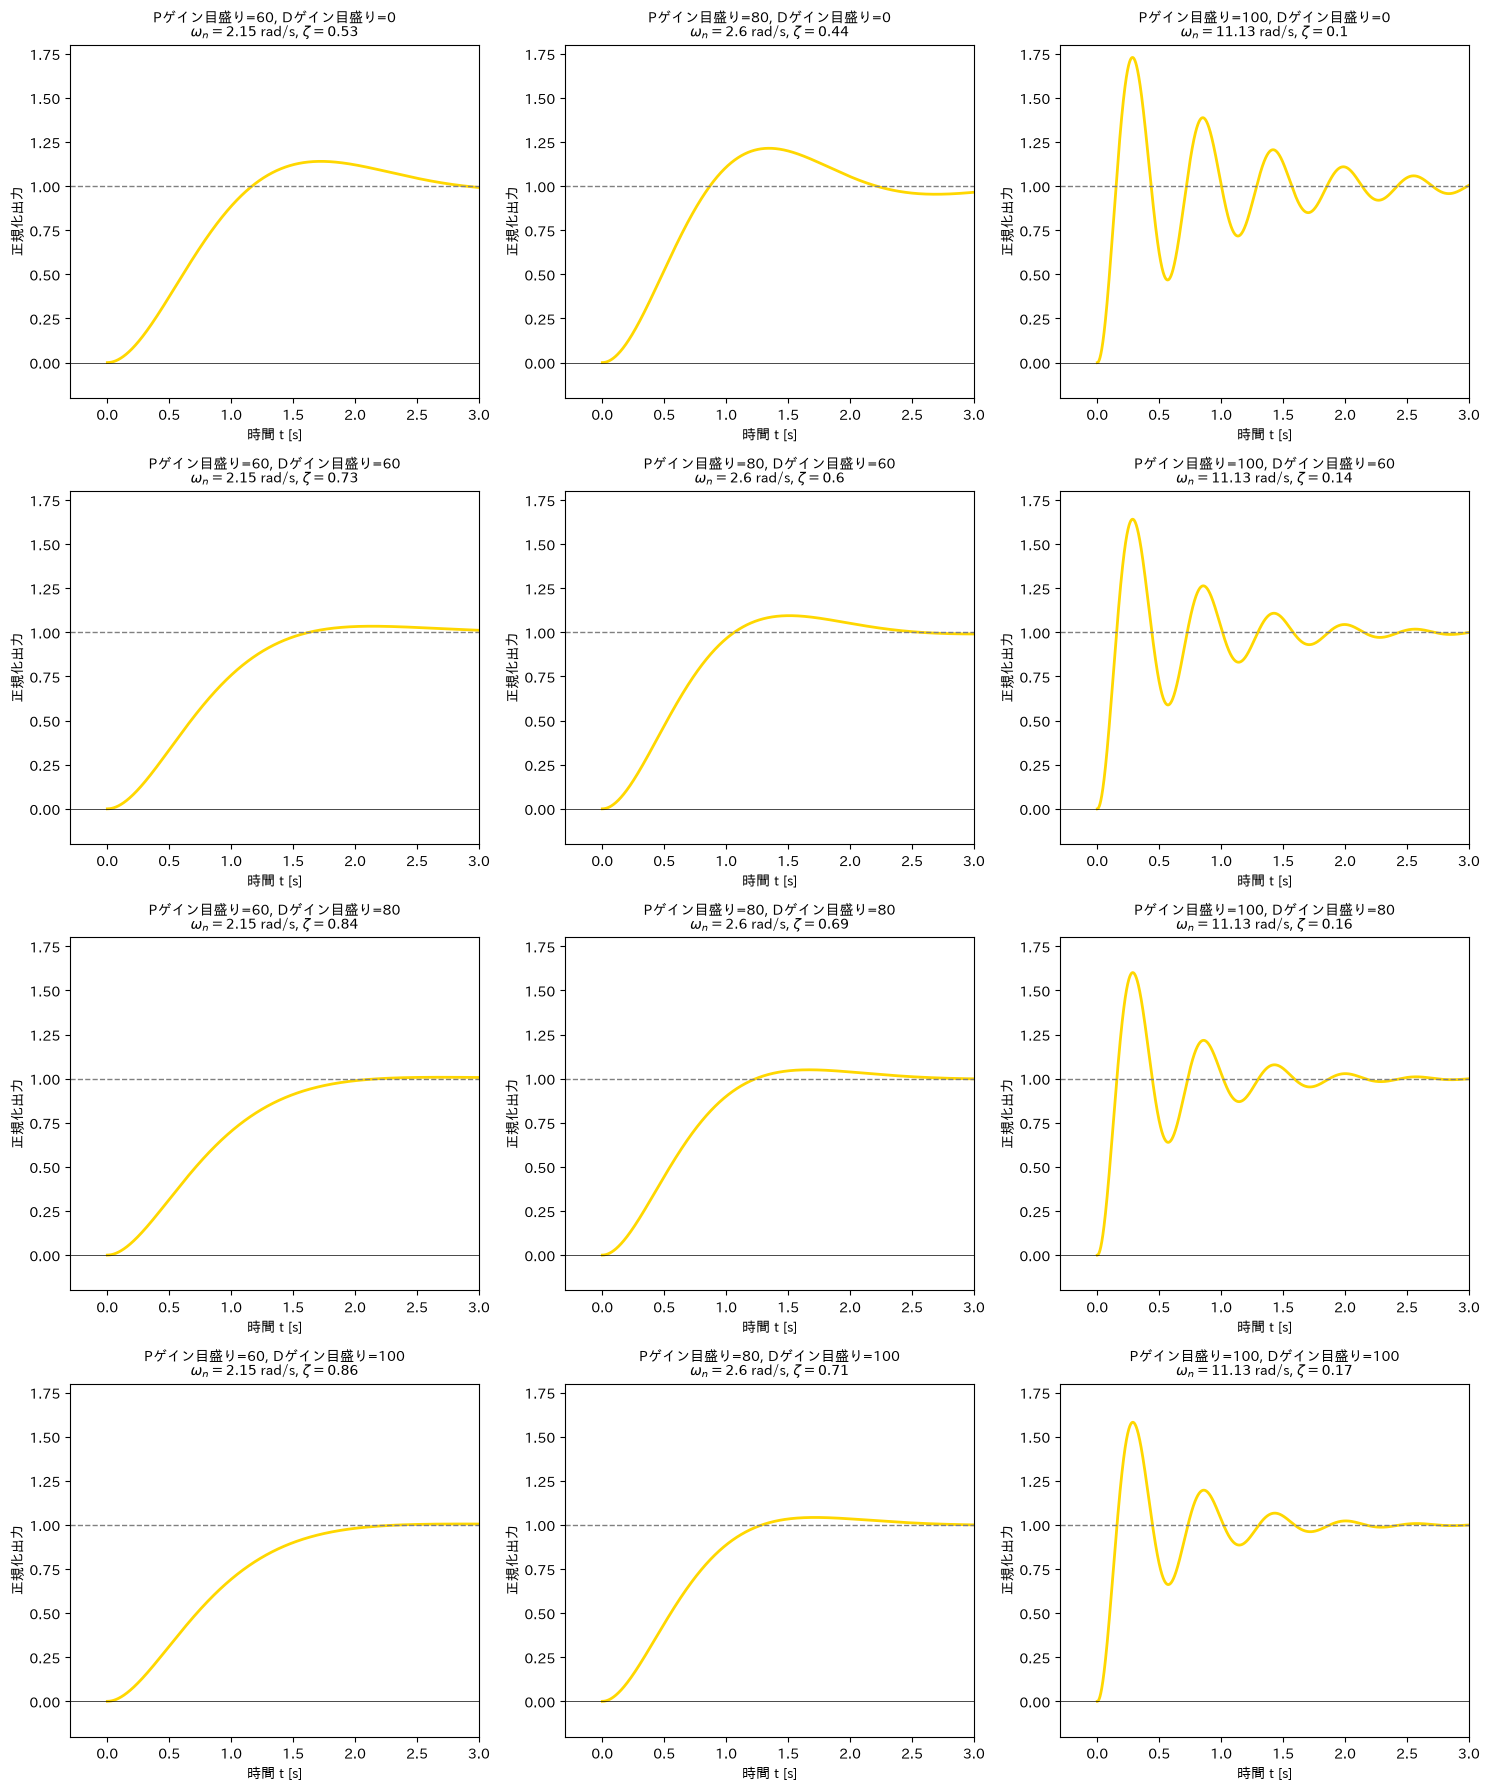

In [4]:
from control.matlab import *
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np

# === パラメータ（実験結果より）===
# (omega_n, zeta)
params = {
    # SW2 OFF (D=0)
    ('P=60',  'D=0'):  (2.15, 0.53),
    ('P=80',  'D=0'):  (2.60, 0.44),
    ('P=100', 'D=0'):  (11.13, 0.10),
    # D=60
    ('P=60',  'D=60'): (2.15, 0.73),
    ('P=80',  'D=60'): (2.60, 0.60),
    ('P=100', 'D=60'): (11.13, 0.14),
    # D=80
    ('P=60',  'D=80'): (2.15, 0.84),
    ('P=80',  'D=80'): (2.60, 0.69),
    ('P=100', 'D=80'): (11.13, 0.16),
    # D=100
    ('P=60',  'D=100'): (2.15, 0.86),
    ('P=80',  'D=100'): (2.60, 0.71),
    ('P=100', 'D=100'): (11.13, 0.17),
}

t = np.linspace(0, 3, 10000)

p_labels = ['P=60', 'P=80', 'P=100']
d_labels = ['D=0', 'D=60', 'D=80', 'D=100']

fig, axes = plt.subplots(4, 3, figsize=(15, 18))

for row, d_label in enumerate(d_labels):
    for col, p_label in enumerate(p_labels):
        omega_n, zeta = params[(p_label, d_label)]
        
        den = [1, 2*zeta*omega_n, omega_n**2]
        num = [omega_n**2]
        system = tf(num, den)
        yout, tout = step(system, T=t)
        
        ax = axes[row][col]
        ax.plot(tout, yout, linewidth=2, color='gold')
        ax.set_xlim(-0.3, 3)
        ax.set_ylim(-0.2, 1.8)
        ax.axhline(1, color='gray', linestyle='--', linewidth=1)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.set_xlabel('時間 t [s]', fontsize=10)
        ax.set_ylabel('正規化出力', fontsize=10)
        ax.set_title(
            f'Pゲイン目盛り={p_label[2:]}, Dゲイン目盛り={d_label[2:]}\n'
            f'$\\omega_n={omega_n}$ rad/s, $\\zeta={zeta}$',
            fontsize=10
        )

plt.tight_layout()
plt.savefig('./images/step_response_all.png', dpi=150, bbox_inches='tight')
plt.show()